In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer

In [2]:
df = pd.read_csv('train_data.csv')
df.head()

,FarmerID,State,REGION,SEX,CITY,Zipcode,DISTRICT,VILLAGE,MARITAL_STATUS,Location,...,Rabi Seasons Agro Ecological Sub Zone in 2020,Rabi Seasons Seasonal average groundwater thickness (cm) in 2020,Rabi Seasons Seasonal average groundwater replenishment rate (cm) in 2020,Night light index,Village score based on socio-economic parameters (Non normalised),Village score based on socio-economic parameters (0 to 100),"Village category based on socio-economic parameters (Good, Average, Poor)",Land Holding Index source (Total Agri Area/ no of people),Road density (Km/ SqKm),Target_Variable/Total Income
0,1887256993454030,ODISHA,EAST,M,MALKANGIRI,764045,MALKANGIRI,Malkangiri,M,NaN,...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,66.75,31.60,0.86,31.72,48.66,Average,0.62,5.49,1580000
1,1106879440316580,TELANGANA,SOUTH,M,MAHABUBABAD,506101,MAHABUBABAD,Mahabubabad,M,NaN,...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,76.50,20.65,0.70,30.79,47.16,Average,17.30,4.09,1000000
2,3650476011422490,TELANGANA,SOUTH,M,PENPAHAD,508201,SURYAPET,Lingala,M,"16.8379908,79.7474909",...,DECCAN PLATEAU (TELANGANA) AND EASTERN GHATS ...,73.84,15.88,0.89,23.80,35.82,Poor,0.64,2.14,1152000
3,1663099265314970,UTTAR PRADESH,NORTH,M,MAINPURI,205001,MAINPURI,Lalupura,M,"27.2387764,79.0699846",...,NORTHERN PLAIN (AND CENTRAL HIGHLANDS) INCLUDI...,45.35,5.19,0.95,25.07,37.89,Poor,0.02,0.00,600000
4,3523662478105830,MADHYA PRADESH,CENTRAL,M,PIPARIYA,461990,HOSHANGABAD,Amgaon,M,NaN,...,EASTERN PLATEAU (CHHOTANAGPUR) AND EASTERN GHA...,99.30,19.06,0.98,26.73,40.57,Average,0.14,2.97,970000


In [4]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

skewed_cols = [
    'Non_Agriculture_Income',
    'Total_Land_For_Agriculture',
    'Target_Variable/Total Income',
    'Avg_Disbursement_Amount_Bureau'
]

agri_keywords = ['Kharif', 'Rabi', 'Agri', 'Rainfall', 'temperature', 'groundwater', 'Irrigated']

agri_cols = [
    col for col in df.select_dtypes(include=['number']).columns
    if any(kw in col for kw in agri_keywords)
]

all_numeric = df.select_dtypes(include=['number']).columns.tolist()

stable_cols = [
    col for col in all_numeric
    if col not in skewed_cols and col not in agri_cols
]

print("Categorical:", len(cat_cols))
print("Skewed:", len(skewed_cols))
print("Agri:", len(agri_cols))
print("Stable:", len(stable_cols))

Categorical: 38
Skewed: 4
Agri: 46
Stable: 19


In [5]:
for col in cat_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

In [6]:
for col in skewed_cols:
    if col in df.columns and df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

In [7]:
for col in stable_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

In [8]:
if agri_cols:
    knn_imputer = KNNImputer(n_neighbors=5)
    df[agri_cols] = knn_imputer.fit_transform(df[agri_cols])

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [10]:
def cap_outliers_iqr(dataframe, columns):
    df_capped = dataframe.copy()
    
    for col in columns:
        if col in df_capped.columns:
            Q1 = df_capped[col].quantile(0.25)
            Q3 = df_capped[col].quantile(0.75)
            
            IQR = Q3 - Q1
            
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            df_capped[col] = np.where(
                df_capped[col] < lower_bound,
                lower_bound,
                np.where(
                    df_capped[col] > upper_bound,
                    upper_bound,
                    df_capped[col]
                )
            )
    
    return df_capped

In [11]:
df_final = cap_outliers_iqr(df, all_numeric)

In [12]:
cols_to_drop = [
    'FarmerID', 'Zipcode', 'CITY',
    'DISTRICT', 'VILLAGE', 'K022-Nearest Mandi Name'
]

cols_to_drop = [col for col in cols_to_drop if col in df_final.columns]

df_engineered = df_final.drop(columns=cols_to_drop)

In [14]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df_engineered.select_dtypes(include=['object']).columns.tolist()

label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_engineered[col] = le.fit_transform(df_engineered[col].astype(str))
    label_encoders[col] = le

In [15]:
target_col = 'Target_Variable/Total Income'

X = df_engineered.drop(columns=[target_col])
y = df_engineered[target_col]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
y_train_log = np.log1p(y_train)

In [18]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_log)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
y_pred_log = rf_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

In [20]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

R2: 0.5334896310670904
MAE: 208934.180451175
RMSE: 310292.2463981669
MAPE: 0.208995027619027


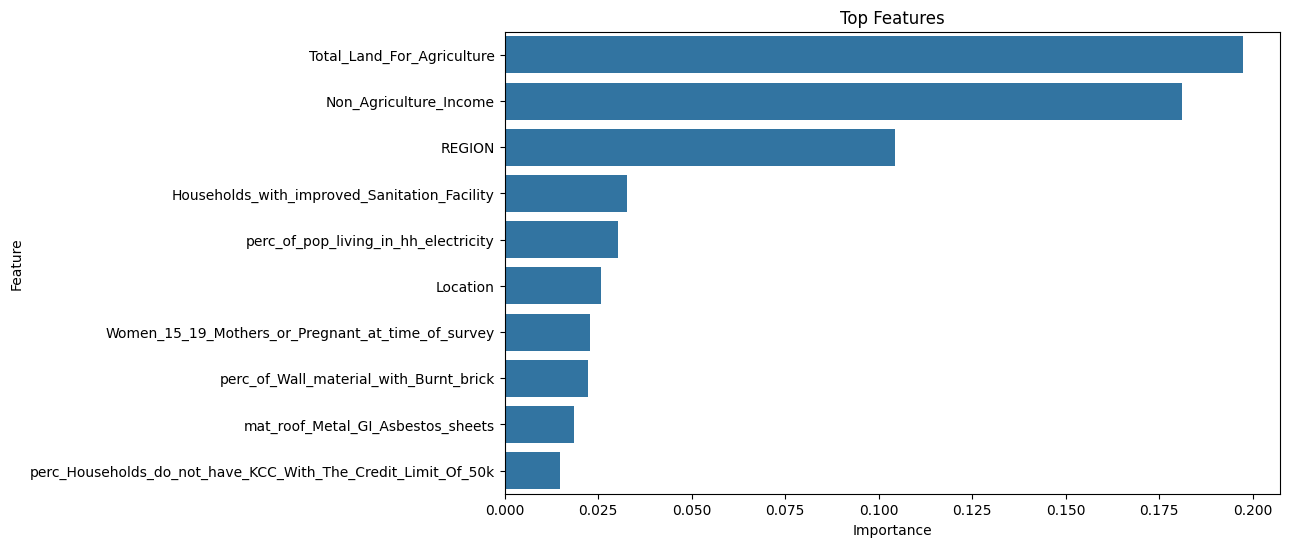

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importances.head(10)
)
plt.title('Top Features')
plt.show()

In [23]:
df_test = pd.read_csv('test_data.csv')

In [24]:
farmer_ids = df_test['FarmerID'] if 'FarmerID' in df_test.columns else df_test.index

In [25]:
for col in cat_cols:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(df_test[col].mode()[0])

for col in skewed_cols:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(df_test[col].median())

for col in stable_cols:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(df_test[col].mean())

if agri_cols:
    df_test[agri_cols] = knn_imputer.transform(df_test[agri_cols])

In [26]:
df_test = cap_outliers_iqr(df_test, all_numeric)

In [27]:
df_test_engineered = df_test.drop(columns=[c for c in cols_to_drop if c in df_test.columns])

In [28]:
for col in cat_cols:
    if col in df_test_engineered.columns:
        le = label_encoders[col]
        known_classes = list(le.classes_)
        
        df_test_engineered[col] = df_test_engineered[col].astype(str)
        df_test_engineered[col] = df_test_engineered[col].apply(
            lambda x: x if x in known_classes else known_classes[0]
        )
        
        df_test_engineered[col] = le.transform(df_test_engineered[col])

In [29]:
X_test_final = df_test_engineered[X.columns]

In [30]:
final_predictions = np.expm1(rf_model.predict(X_test_final))

In [31]:
submission = pd.DataFrame({
    'FarmerID': farmer_ids,
    'Target_Variable/Total Income': final_predictions
})

submission.to_csv('TeamName_predictions.csv', index=False)